# Robust Evaluation

## Notebook Contract
- **Objective:** demonstrate the v0.4 robust-evaluation workflow: calibration (reliability diagram + ECE), threshold tuning, bootstrap confidence intervals on classification metrics, subgroup metrics, and prediction drift between two datasets.
- **Inputs:** synthetic support-ticket data generated locally.
- **Outputs:** calibration table, reliability plot, threshold-sweep table, bootstrap CI summary, subgroup metric table, and a drift table written under `reports/sample_run/`.
- **Expected runtime:** under 1 minute on CPU.
- **Scope boundary:** all stats live in `src/hf_finetuning_lab/evaluation/robust.py`; this notebook orchestrates and visualizes.

## 1) Setup and Reproducibility

In [1]:
from __future__ import annotations

import os
import platform
import random
import sys
from datetime import UTC, datetime
from pathlib import Path

ROOT = Path('..').resolve()
SRC_PATH = ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

from hf_finetuning_lab.data.io import validate_text_classification_frame
from hf_finetuning_lab.evaluation.robust import (
    bootstrap_metric,
    expected_calibration_error,
    find_best_threshold,
    prediction_share_drift,
    reliability_curve,
    subgroup_metrics,
)
from hf_finetuning_lab.sample_data import write_sample_data

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print(f'Python: {sys.version.split()[0]}')
print(f'Platform: {platform.platform()}')
print(f"Timestamp (UTC): {datetime.now(UTC).isoformat(timespec='seconds')}")
print(f'Seed: {SEED}')

Python: 3.12.11
Platform: Windows-11-10.0.26200-SP0
Timestamp (UTC): 2026-05-17T20:29:33+00:00
Seed: 42


## 2) Parameters

We treat the multiclass support-ticket task and also derive a binary view (`billing` vs other) so the calibration and threshold sections have a clean positive-class probability to work with.

In [2]:
DATA_PATH = ROOT / 'data' / 'raw' / 'support_tickets.csv'
REPORTS_DIR = ROOT / 'reports' / 'sample_run'
CALIBRATION_PATH = REPORTS_DIR / 'calibration_curve.csv'
BOOTSTRAP_PATH = REPORTS_DIR / 'bootstrap_metrics.csv'
SUBGROUP_PATH = REPORTS_DIR / 'subgroup_metrics.csv'
DRIFT_PATH = REPORTS_DIR / 'prediction_drift.csv'

TEXT_COL = 'text'
LABEL_COL = 'label'
POSITIVE_CLASS = 'billing'
ROWS = 800
TEST_SIZE = 0.25
N_BOOTSTRAP = 300
N_BINS = 10

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
print(f'Reports dir: {REPORTS_DIR}')
print(f'Binary positive class: {POSITIVE_CLASS!r}')

Reports dir: C:\Users\diogo\work_code\portfolio\huggingface-finetuning-lab\reports\sample_run
Binary positive class: 'billing'


## 3) Data and Two-Stage Model

Train a multiclass model for subgroup and drift work, plus a binary `billing`-vs-other model so calibration and threshold sweeps have a well-defined positive-class probability.

In [3]:
DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
write_sample_data(output=DATA_PATH, rows=ROWS, seed=SEED)

df = pd.read_csv(DATA_PATH)
validate_text_classification_frame(df, text_col=TEXT_COL, label_col=LABEL_COL)
df['is_urgent'] = df[TEXT_COL].str.contains('urgent', case=False, regex=False)
df['binary'] = (df[LABEL_COL] == POSITIVE_CLASS).astype(int)

train_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=df[LABEL_COL],
)
print(f'Train rows: {len(train_df)} | Test rows: {len(test_df)}')
print(f"Positive class share (test): {test_df['binary'].mean():.3f}")
print(f"Urgent share (test): {test_df['is_urgent'].mean():.3f}")

Train rows: 600 | Test rows: 200
Positive class share (test): 0.170
Urgent share (test): 0.115


In [4]:
def make_pipeline() -> Pipeline:
    return Pipeline(
        steps=[
            ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_features=12000)),
            ('clf', LogisticRegression(max_iter=1000, random_state=SEED)),
        ]
    )


multiclass_model = make_pipeline().fit(train_df[TEXT_COL], train_df[LABEL_COL])
binary_model = make_pipeline().fit(train_df[TEXT_COL], train_df['binary'])

multiclass_pred = multiclass_model.predict(test_df[TEXT_COL])
binary_pred = binary_model.predict(test_df[TEXT_COL])
binary_prob = binary_model.predict_proba(test_df[TEXT_COL])[:, 1]

print(f"Multiclass macro F1: {f1_score(test_df[LABEL_COL], multiclass_pred, average='macro'):.4f}")
print(f"Binary F1 (positive class): {f1_score(test_df['binary'], binary_pred, average='binary'):.4f}")

Multiclass macro F1: 1.0000
Binary F1 (positive class): 1.0000


## 4) Calibration: Reliability Diagram and ECE

We bucket samples by the binary model's confidence on the positive class, then compare each bucket's mean confidence to its observed accuracy. A well-calibrated classifier lies near the diagonal; ECE summarizes the weighted gap.

In [5]:
y_true_binary = test_df['binary'].to_numpy()
curve = reliability_curve(y_true_binary, binary_prob, n_bins=N_BINS)
ece = expected_calibration_error(y_true_binary, binary_prob, n_bins=N_BINS)
curve.to_csv(CALIBRATION_PATH, index=False)
print(f'Expected Calibration Error: {ece:.4f}')
print(f'Calibration table written to: {CALIBRATION_PATH}')
curve_display = curve.round(4)
curve_display

Expected Calibration Error: 0.0749
Calibration table written to: C:\Users\diogo\work_code\portfolio\huggingface-finetuning-lab\reports\sample_run\calibration_curve.csv


,bin_lower,bin_upper,mean_confidence,accuracy,count
0,0.6,0.7,0.6659,1.0,5
1,0.7,0.8,0.7449,1.0,16
2,0.8,0.9,0.8351,1.0,10
3,0.9,1.0,0.9552,1.0,169


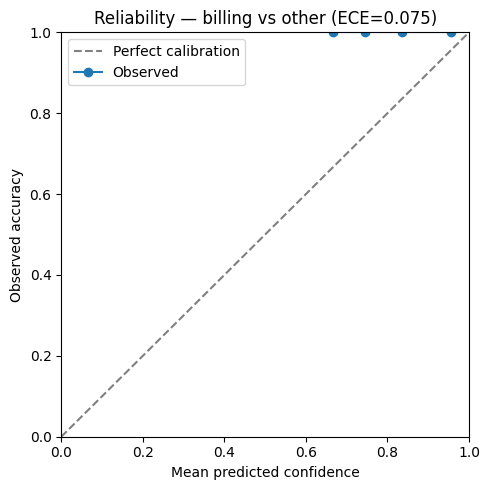

In [6]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Perfect calibration')
ax.plot(curve['mean_confidence'], curve['accuracy'], marker='o', label='Observed')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel('Mean predicted confidence')
ax.set_ylabel('Observed accuracy')
ax.set_title(f'Reliability — billing vs other (ECE={ece:.3f})')
ax.legend()
fig.tight_layout()
plt.show()

## 5) Threshold Tuning

Default `0.5` rarely maximizes F1 on imbalanced tasks. Sweep thresholds and pick the one that maximizes macro F1 on the binary task.

In [7]:
def binary_f1(y_true, y_pred):
    return float(f1_score(y_true, y_pred, average='binary', zero_division=0))


thresholds = np.linspace(0.05, 0.95, 19)
scores = pd.DataFrame(
    {
        'threshold': thresholds,
        'f1': [binary_f1(y_true_binary, (binary_prob >= t).astype(int)) for t in thresholds],
        'accuracy': [
            float(accuracy_score(y_true_binary, (binary_prob >= t).astype(int))) for t in thresholds
        ],
    }
)
best = find_best_threshold(y_true_binary, binary_prob, metric_fn=binary_f1, thresholds=thresholds)
print(f"Best threshold: {best['threshold']:.2f} | F1 at best: {best['metric']:.4f}")
print(f"Default threshold 0.50 F1:    {binary_f1(y_true_binary, (binary_prob >= 0.5).astype(int)):.4f}")
scores.round(4)

Best threshold: 0.10 | F1 at best: 1.0000
Default threshold 0.50 F1:    1.0000


,threshold,f1,accuracy
0,0.05,0.6415,0.810
1,0.10,1.0000,1.000
2,0.15,1.0000,1.000
3,0.20,1.0000,1.000
4,0.25,1.0000,1.000
5,0.30,1.0000,1.000
6,0.35,1.0000,1.000
7,0.40,1.0000,1.000
8,0.45,1.0000,1.000
9,0.50,1.0000,1.000


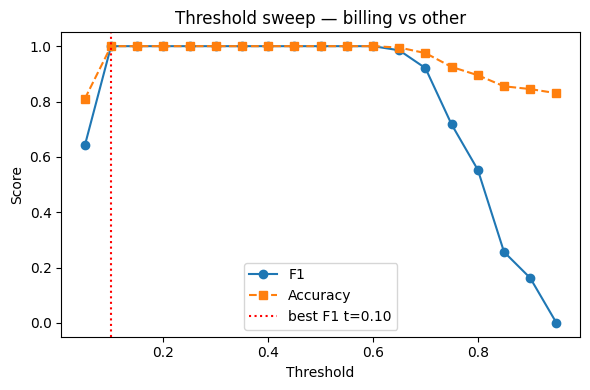

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(scores['threshold'], scores['f1'], marker='o', label='F1')
ax.plot(scores['threshold'], scores['accuracy'], marker='s', linestyle='--', label='Accuracy')
ax.axvline(best['threshold'], color='red', linestyle=':', label=f"best F1 t={best['threshold']:.2f}")
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold sweep — billing vs other')
ax.legend()
fig.tight_layout()
plt.show()

## 6) Bootstrap Confidence Intervals

A point estimate on one test split tells us little about run-to-run variance. Resample the test set with replacement to bracket macro F1 and weighted F1 with a 95% interval.

In [9]:
y_true_multi = test_df[LABEL_COL].to_numpy()

boot_results = {
    'macro_f1': bootstrap_metric(
        y_true_multi,
        multiclass_pred,
        metric_fn=lambda yt, yp: float(f1_score(yt, yp, average='macro', zero_division=0)),
        n_iter=N_BOOTSTRAP,
        seed=SEED,
    ),
    'weighted_f1': bootstrap_metric(
        y_true_multi,
        multiclass_pred,
        metric_fn=lambda yt, yp: float(f1_score(yt, yp, average='weighted', zero_division=0)),
        n_iter=N_BOOTSTRAP,
        seed=SEED,
    ),
    'binary_f1': bootstrap_metric(
        y_true_binary,
        binary_pred,
        metric_fn=binary_f1,
        n_iter=N_BOOTSTRAP,
        seed=SEED,
    ),
}
boot_frame = pd.DataFrame(boot_results).T.reset_index().rename(columns={'index': 'metric'})
boot_frame.to_csv(BOOTSTRAP_PATH, index=False)
print(f'Bootstrap results written to: {BOOTSTRAP_PATH}')
boot_frame.round(4)

Bootstrap results written to: C:\Users\diogo\work_code\portfolio\huggingface-finetuning-lab\reports\sample_run\bootstrap_metrics.csv


,metric,value,ci_low,ci_high,n_iter
0,macro_f1,1.0,1.0,1.0,300.0
1,weighted_f1,1.0,1.0,1.0,300.0
2,binary_f1,1.0,1.0,1.0,300.0


## 7) Subgroup Metrics

Aggregate metrics can hide failures on smaller slices. Use the synthetic `is_urgent` flag (extracted from the ticket text in cell 3) as a stand-in for a real-world subgroup.

In [10]:
subgroup_table = subgroup_metrics(
    y_true_multi,
    multiclass_pred,
    groups=test_df['is_urgent'].to_numpy(),
    metric_fns={
        'macro_f1': lambda yt, yp: float(f1_score(yt, yp, average='macro', zero_division=0)),
        'weighted_f1': lambda yt, yp: float(f1_score(yt, yp, average='weighted', zero_division=0)),
        'accuracy': lambda yt, yp: float(accuracy_score(yt, yp)),
    },
)
subgroup_table.index = subgroup_table.index.map({True: 'urgent', False: 'non-urgent'})
subgroup_table.index.name = 'group'
subgroup_table.to_csv(SUBGROUP_PATH)
print(f'Subgroup metrics written to: {SUBGROUP_PATH}')
subgroup_table.round(4)

Subgroup metrics written to: C:\Users\diogo\work_code\portfolio\huggingface-finetuning-lab\reports\sample_run\subgroup_metrics.csv


,count,macro_f1,weighted_f1,accuracy
group,,,,
non-urgent,177,1.0,1.0,1.0
urgent,23,1.0,1.0,1.0


## 8) Prediction Drift

Compare the label-share distribution between two prediction sets. Here we predict on the train split and the test split; in production this would be `predictions yesterday` vs `predictions today`. PSI > 0.1 is a common 'investigate' threshold; > 0.25 is a 'this is a different distribution' threshold.

In [11]:
train_pred = multiclass_model.predict(train_df[TEXT_COL])
test_pred = multiclass_pred
drift = prediction_share_drift(train_pred, test_pred)
drift.to_csv(DRIFT_PATH, index=False)
print(f"PSI total: {drift.attrs['psi_total']:.4f}")
print(f'Drift table written to: {DRIFT_PATH}')
drift.round(4)

PSI total: 0.0002
Drift table written to: C:\Users\diogo\work_code\portfolio\huggingface-finetuning-lab\reports\sample_run\prediction_drift.csv


,label,share_a,share_b,delta,psi
0,account,0.1900,0.190,0.0000,0.0000
1,billing,0.1700,0.170,0.0000,0.0000
2,cancellation,0.1217,0.125,0.0033,0.0001
3,delivery,0.1183,0.115,-0.0033,0.0001
4,security,0.1933,0.195,0.0017,0.0000
5,technical,0.2067,0.205,-0.0017,0.0000


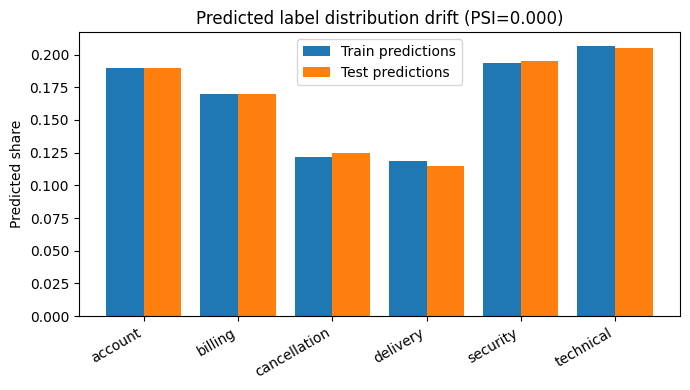

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(drift))
ax.bar(x - 0.2, drift['share_a'], width=0.4, label='Train predictions')
ax.bar(x + 0.2, drift['share_b'], width=0.4, label='Test predictions')
ax.set_xticks(x)
ax.set_xticklabels(drift['label'], rotation=30, ha='right')
ax.set_ylabel('Predicted share')
ax.set_title(f"Predicted label distribution drift (PSI={drift.attrs['psi_total']:.3f})")
ax.legend()
fig.tight_layout()
plt.show()

## 9) Checklist
- Calibration curve and ECE quantify whether the model's confidence is trustworthy on the binary view.
- Threshold sweep shows the F1 trade-off and the best operating point versus the default `0.5`.
- Bootstrap CIs put run-to-run variance bounds around macro/weighted/binary F1.
- Subgroup metrics compare urgent vs non-urgent tickets — replace the urgency flag with a real protected or operational attribute for production use.
- Prediction drift compares train-time vs test-time predicted label shares and reports PSI.
- All outputs are written under `reports/sample_run/` so they can be diffed across notebook runs.